# 06 — Supervised Balanced Random Forest

This notebook:
- loads the prepared train, validation, and test splits,
- trains the binary Balanced Random Forest model,
- evaluates validation and test performance,
- plots feature importance,
- compares SBS96 importance with the COSMIC SBS4 profile.


In [14]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
)
from sklearn.metrics.pairwise import cosine_similarity
from imblearn.ensemble import BalancedRandomForestClassifier

PROJECT_ROOT = Path.cwd().resolve()

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)

## 1. Define paths


In [15]:
split_output_dir = PROJECT_ROOT / "results" / "brf_split_binary"
plot_dir = PROJECT_ROOT / "plots" / "brf_split_binary"
cosmic_sbs4_path = PROJECT_ROOT / "data" / "v3.2_SBS4_DIFFERENCE.txt"

plot_dir.mkdir(parents=True, exist_ok=True)

train_path = split_output_dir / "train.csv"
val_path = split_output_dir / "val.csv"
test_path = split_output_dir / "test.csv"

display(
    pd.DataFrame({
        "file": ["train", "validation", "test", "plot dir", "COSMIC SBS4"],
        "path": [train_path, val_path, test_path, plot_dir, cosmic_sbs4_path],
    })
)

,file,path
0,train,/Users/michaljendrusak/PycharmProjects/tcga-lu...
1,validation,/Users/michaljendrusak/PycharmProjects/tcga-lu...
2,test,/Users/michaljendrusak/PycharmProjects/tcga-lu...
3,plot dir,/Users/michaljendrusak/PycharmProjects/tcga-lu...
4,COSMIC SBS4,/Users/michaljendrusak/PycharmProjects/tcga-lu...


## 2. Load the split tables


In [16]:
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

sbs_cols = [
    col for col in train_df.columns
    if "[" in str(col) and ">" in str(col) and "]" in str(col)
]

display(
    pd.DataFrame({
        "table": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "columns": [train_df.shape[1], val_df.shape[1], test_df.shape[1]],
    })
)

display(
    pd.DataFrame({
        "item": ["number of mutation channels"],
        "value": [len(sbs_cols)],
    })
)

display(train_df.head())

,table,rows,columns
0,train,315,105
1,validation,79,105
2,test,99,105


,item,value
0,number of mutation channels,96


,Patient_ID,exposures.tobacco_smoking_status,exposures.pack_years_smoked,demographic.age_at_index,demographic.gender,demographic.race,demographic.ethnicity,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,A[C>G]A,A[C>G]C,A[C>G]G,A[C>G]T,A[C>T]A,A[C>T]C,A[C>T]G,A[C>T]T,A[T>A]A,A[T>A]C,A[T>A]G,A[T>A]T,A[T>C]A,A[T>C]C,A[T>C]G,A[T>C]T,A[T>G]A,A[T>G]C,A[T>G]G,A[T>G]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,C[C>G]A,C[C>G]C,C[C>G]G,C[C>G]T,C[C>T]A,C[C>T]C,C[C>T]G,C[C>T]T,C[T>A]A,C[T>A]C,C[T>A]G,C[T>A]T,C[T>C]A,C[T>C]C,C[T>C]G,C[T>C]T,C[T>G]A,C[T>G]C,C[T>G]G,C[T>G]T,G[C>A]A,G[C>A]C,G[C>A]G,G[C>A]T,G[C>G]A,G[C>G]C,G[C>G]G,G[C>G]T,G[C>T]A,G[C>T]C,G[C>T]G,G[C>T]T,G[T>A]A,G[T>A]C,G[T>A]G,G[T>A]T,G[T>C]A,G[T>C]C,G[T>C]G,G[T>C]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[C>A]A,T[C>A]C,T[C>A]G,T[C>A]T,T[C>G]A,T[C>G]C,T[C>G]G,T[C>G]T,T[C>T]A,T[C>T]C,T[C>T]G,T[C>T]T,T[T>A]A,T[T>A]C,T[T>A]G,T[T>A]T,T[T>C]A,T[T>C]C,T[T>C]G,T[T>C]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T,Smoking_3,Smoking_Bin
0,TCGA-67-3773,Current Reformed Smoker for > 15 yrs,NaN,84.0,female,white,not hispanic or latino,3.0,5.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,3.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,7.0,5.0,3.0,3.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,4.0,3.0,0.0,0.0,0.0,0.0,3.0,2.0,3.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0,4.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,Former,1
1,TCGA-NJ-A7XG,Current Reformed Smoker for > 15 yrs,NaN,49.0,male,black or african american,not hispanic or latino,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Former,1
2,TCGA-91-6848,Current Reformed Smoker for < or = 15 yrs,NaN,59.0,male,white,not hispanic or latino,11.0,12.0,9.0,5.0,4.0,6.0,5.0,6.0,9.0,4.0,4.0,8.0,1.0,3.0,2.0,0.0,10.0,2.0,7.0,3.0,1.0,2.0,2.0,1.0,26.0,23.0,12.0,29.0,7.0,8.0,4.0,7.0,9.0,10.0,8.0,14.0,0.0,3.0,12.0,3.0,4.0,4.0,6.0,3.0,0.0,2.0,7.0,1.0,14.0,17.0,5.0,5.0,8.0,4.0,5.0,4.0,6.0,6.0,2.0,5.0,2.0,3.0,3.0,2.0,7.0,2.0,2.0,7.0,0.0,0.0,1.0,0.0,12.0,24.0,5.0,16.0,19.0,2.0,3.0,21.0,22.0,10.0,6.0,14.0,1.0,2.0,5.0,0.0,3.0,3.0,2.0,0.0,0.0,0.0,3.0,1.0,Former,1
3,TCGA-55-6986,Lifelong Non-Smoker,NaN,74.0,female,white,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Never,0
4,TCGA-73-4677,Current Reformed Smoker for > 15 yrs,NaN,74.0,male,white,not hispanic or latino,12.0,10.0,0.0,4.0,2.0,5.0,1.0,2.0,2.0,2.0,5.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,18.0,15.0,1.0,11.0,2.0,1.0,0.0,2.0,5.0,4.0,6.0,8.0,1.0,1.0,4.0,0.0,1.0,2.0,4.0,0.0,0.0,0.0,0.0,2.0,9.0,11.0,3.0,7.0,0.0,1.0,1.0,2.0,7.0,5.0,1.0,4.0,0.0,3.0,3.0,1.0,0.0,5.0,2.0,0.0,0.0,0.0,0.0,1.0,4.0,8.0,5.0,7.0,4.0,2.0,0.0,2.0,7.0,6.0,4.0,3.0,1.0,1.0,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Former,1


## 3. Prepare the feature matrices


In [17]:
def prep_features(frame, sbs_cols, age_median=None):
    frame = frame.copy()

    frame["demographic.age_at_index"] = pd.to_numeric(
        frame["demographic.age_at_index"],
        errors="coerce"
    )

    frame["demographic.gender"] = (
        frame["demographic.gender"]
        .astype(str)
        .str.lower()
        .map({"male": 1, "female": 0})
    )

    if age_median is None:
        age_median = frame["demographic.age_at_index"].median()

    frame["demographic.age_at_index"] = frame["demographic.age_at_index"].fillna(age_median)

    X_sbs = frame[sbs_cols].copy()
    X_sbs = X_sbs.div(X_sbs.sum(axis=1), axis=0).fillna(0.0)

    X_clin = frame[["demographic.age_at_index", "demographic.gender"]].copy()
    X_clin = X_clin.rename(columns={"demographic.age_at_index": "age_years"})

    X = pd.concat([X_sbs, X_clin], axis=1)
    y = frame["Smoking_Bin"].astype(int)

    return X, y, age_median

In [18]:
X_train, y_train, age_median = prep_features(train_df, sbs_cols)
X_val, y_val, _ = prep_features(val_df, sbs_cols, age_median)
X_test, y_test, _ = prep_features(test_df, sbs_cols, age_median)

display(
    pd.DataFrame({
        "split": ["train", "validation", "test"],
        "n_rows": [len(X_train), len(X_val), len(X_test)],
        "n_features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    })
)

display(pd.DataFrame({"age_median_used": [age_median]}))
display(X_train.iloc[:5, :8].reset_index(drop=True))

,split,n_rows,n_features
0,train,315,98
1,validation,79,98
2,test,99,98


,age_median_used
0,66.0


,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,A[C>G]A,A[C>G]C,A[C>G]G,A[C>G]T
0,0.029412,0.049020,0.009804,0.019608,0.009804,0.000000,0.000000,0.000000
1,0.000000,0.030303,0.000000,0.030303,0.000000,0.000000,0.000000,0.000000
2,0.018242,0.019900,0.014925,0.008292,0.006633,0.009950,0.008292,0.009950
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.045283,0.037736,0.000000,0.015094,0.007547,0.018868,0.003774,0.007547


## 4. Run the manual grid search on the validation set


In [19]:
RANDOM_STATE = 42

results = []
best_score = -1.0
best_params = None
best_model = None

for n_estimators in [200, 400, 800]:
    for max_depth in [None, 20]:
        params = {
            "n_estimators": n_estimators,
            "max_features": "sqrt",
            "max_depth": max_depth,
        }

        model = BalancedRandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            sampling_strategy="auto",
            replacement=False,
            bootstrap=True,
            **params,
        )

        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_proba = model.predict_proba(X_val)[:, 1]

        score_f1 = f1_score(y_val, val_pred, average="macro")
        score_bal = balanced_accuracy_score(y_val, val_pred)

        fpr, tpr, _ = roc_curve(y_val, val_proba)
        score_auc = auc(fpr, tpr)

        results.append({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "val_f1_macro": score_f1,
            "val_balanced_accuracy": score_bal,
            "val_auc": score_auc,
        })

        if score_f1 > best_score:
            best_score = score_f1
            best_params = params
            best_model = model

grid_df = pd.DataFrame(results).sort_values("val_f1_macro", ascending=False).reset_index(drop=True)

display(grid_df)
display(pd.DataFrame([best_params]))
display(pd.DataFrame({"best_validation_macro_f1": [best_score]}))

,n_estimators,max_depth,val_f1_macro,val_balanced_accuracy,val_auc
0,200,NaN,0.725694,0.820856,0.866979
1,200,20.0,0.725694,0.820856,0.866979
2,800,20.0,0.712727,0.813503,0.871658
3,800,NaN,0.712727,0.813503,0.871658
4,400,20.0,0.700190,0.806150,0.860963
5,400,NaN,0.700190,0.806150,0.860963


,n_estimators,max_features,max_depth
0,200,sqrt,None


,best_validation_macro_f1
0,0.725694


## 5. Define evaluation helpers


In [20]:
def save_report_and_cm_binary(y_true, y_pred, tag):
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    support = len(y_true)

    report_text = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Never", "Ever"],
        zero_division=0,
    )

    report_path = split_output_dir / f"{tag}_report.txt"
    with open(report_path, "w", encoding="utf-8") as handle:
        handle.write(f"accuracy: {accuracy:.4f}\n")
        handle.write(f"balanced_accuracy: {balanced_acc:.4f}\n")
        handle.write(f"f1_macro: {f1_macro:.4f}\n")
        handle.write(f"support: {support}\n\n")
        handle.write(report_text)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Never", "Ever"],
        yticklabels=["Never", "Ever"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{tag} confusion matrix")
    plt.tight_layout()

    plt.savefig(plot_dir / f"{tag}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "f1_macro": f1_macro,
        "support": support,
    }


def plot_binary_roc(y_true, y_score, tag):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curve on the {tag} set")
    plt.legend(loc="lower right")
    plt.tight_layout()

    plt.savefig(plot_dir / f"{tag}_roc.png", dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "auc": roc_auc,
    }


def evaluate_model(model, X, y, tag):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]

    metrics = save_report_and_cm_binary(y, pred, tag)
    roc_info = plot_binary_roc(y, proba, tag)

    return pd.DataFrame([{**metrics, **roc_info}])

## 6. Training-set sanity check


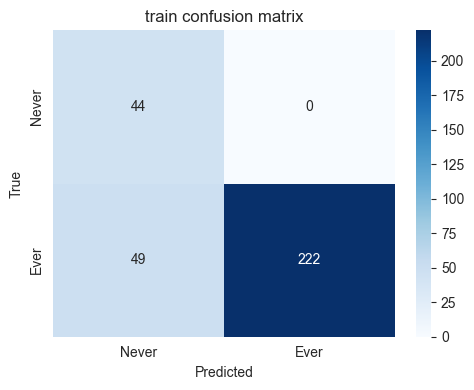

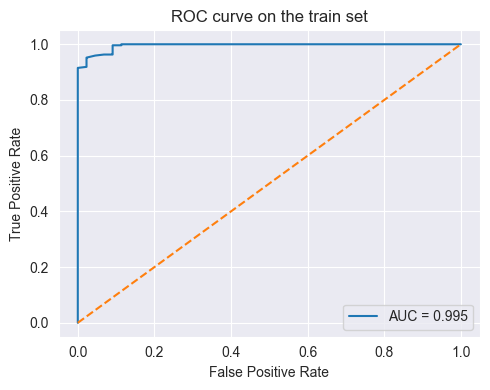

,accuracy,balanced_accuracy,f1_macro,support,auc
0,0.844444,0.909594,0.771472,315,0.995304


In [21]:
brf_selected = best_model

display(evaluate_model(brf_selected, X_train, y_train, "train"))

## 7. Validation-set evaluation


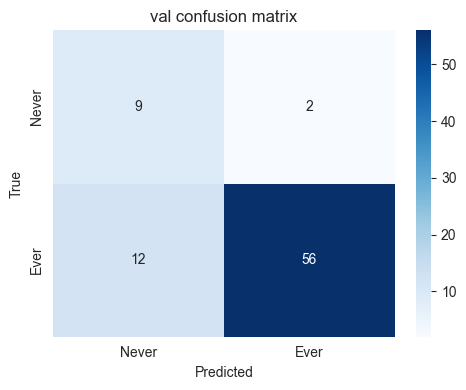

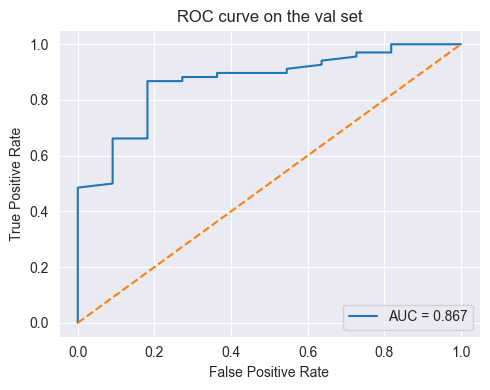

,accuracy,balanced_accuracy,f1_macro,support,auc
0,0.822785,0.820856,0.725694,79,0.866979


In [22]:
display(evaluate_model(brf_selected, X_val, y_val, "val"))

## 8. Train the final model on train + validation and evaluate the test set


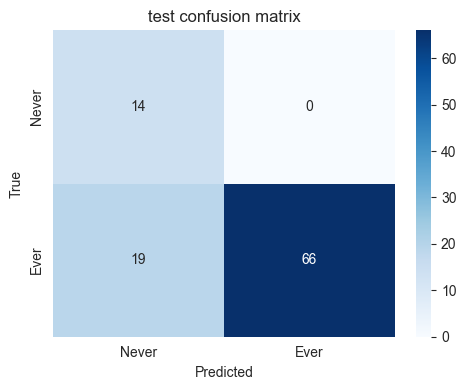

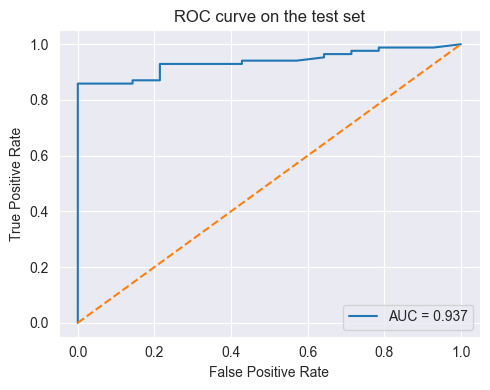

,accuracy,balanced_accuracy,f1_macro,support,auc
0,0.808081,0.888235,0.734958,99,0.936975


In [23]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

brf_final = BalancedRandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    sampling_strategy="auto",
    replacement=False,
    bootstrap=True,
    **best_params,
)

brf_final.fit(X_trainval, y_trainval)

display(evaluate_model(brf_final, X_test, y_test, "test"))

## 9. Plot permutation importance


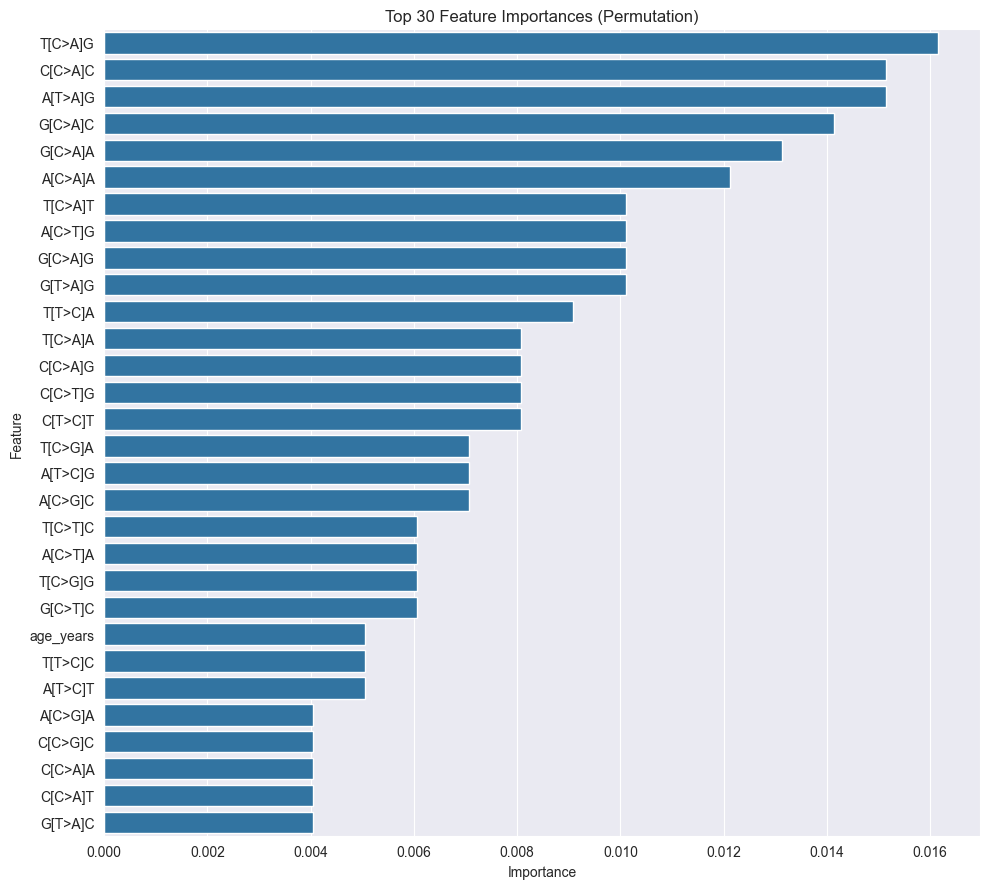

,feature,importance
0,T[C>A]G,0.016162
1,C[C>A]C,0.015152
2,A[T>A]G,0.015152
3,G[C>A]C,0.014141
4,G[C>A]A,0.013131
5,A[C>A]A,0.012121
6,T[C>A]T,0.010101
7,A[C>T]G,0.010101
8,G[C>A]G,0.010101
9,G[T>A]G,0.010101


In [24]:
perm = permutation_importance(
    brf_final,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

perm_importance.to_csv(
    split_output_dir / "feature_importance_permutation.tsv",
    sep="\t",
    header=["importance"]
)

top30_perm = perm_importance.head(30)

plt.figure(figsize=(10, 9))
sns.barplot(x=top30_perm.values, y=top30_perm.index)

plt.title("Top 30 Feature Importances (Permutation)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

perm_path = plot_dir / "feature_importance_top30_permutation.png"
plt.savefig(perm_path, dpi=300, bbox_inches="tight")
plt.show()

display(
    top30_perm.rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

## 11. Feature importance


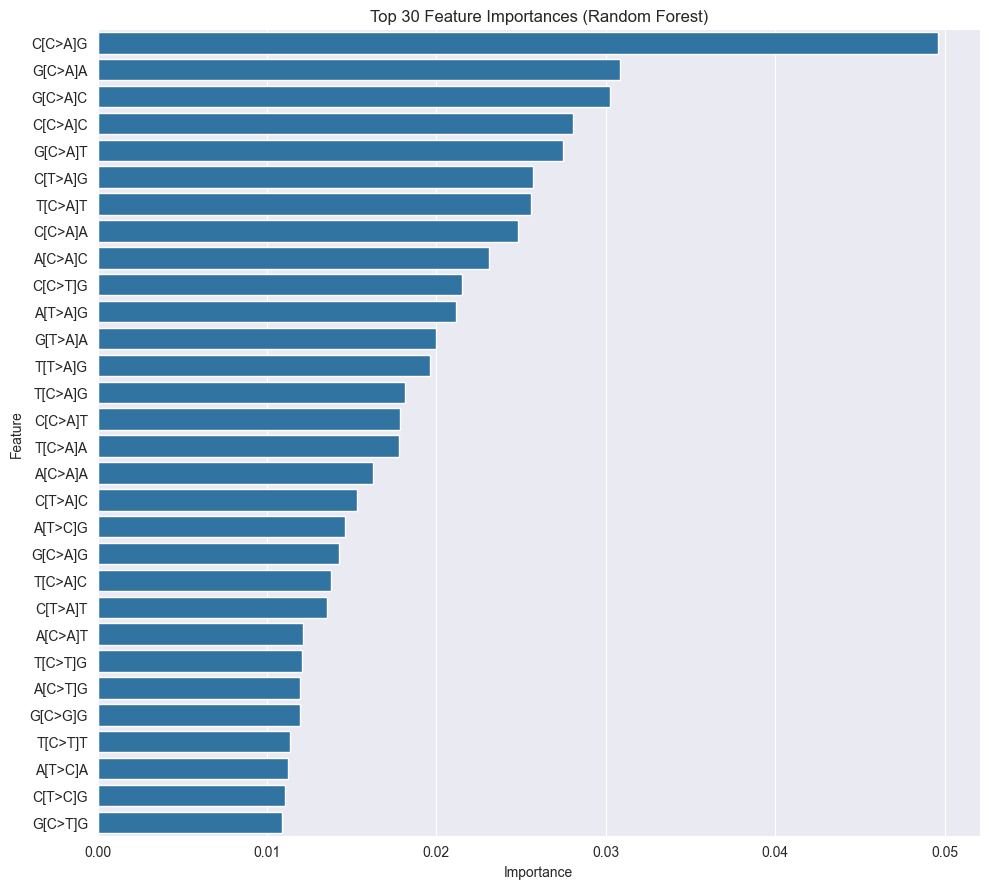

,feature,importance
0,C[C>A]G,0.049609
1,G[C>A]A,0.030836
2,G[C>A]C,0.030264
3,C[C>A]C,0.028073
4,G[C>A]T,0.027443
5,C[T>A]G,0.025674
6,T[C>A]T,0.025591
7,C[C>A]A,0.024823
8,A[C>A]C,0.023094
9,C[C>T]G,0.021511


In [25]:
fi = pd.Series(
    brf_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fi.to_csv(
    split_output_dir / "feature_importance_final_model.tsv",
    sep="\t",
    header=["importance"]
)

top30 = fi.head(30)

plt.figure(figsize=(10, 9))
sns.barplot(x=top30.values, y=top30.index)

plt.title("Top 30 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

fi_path = plot_dir / "feature_importance_top30_final.png"
plt.savefig(fi_path, dpi=300, bbox_inches="tight")
plt.show()

display(
    top30.rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

## 12. Compare the SBS96 importance profile with COSMIC SBS4


In [26]:
cosmic = pd.read_csv(cosmic_sbs4_path, sep="\t", index_col=0)

if "Signature_4_GRCh38" not in cosmic.columns:
    raise KeyError("Column 'Signature_4_GRCh38' is missing in the COSMIC SBS4 file.")

cosmic_sbs4 = cosmic["Signature_4_GRCh38"].copy()
cosmic_sbs4.index = cosmic_sbs4.index.astype(str)
cosmic_sbs4 = cosmic_sbs4.reindex(sbs_cols)

if cosmic_sbs4.isna().any():
    missing_channels = cosmic_sbs4[cosmic_sbs4.isna()].index.tolist()
    raise RuntimeError(f"Missing SBS4 values for channels: {missing_channels}")

imp_vec = fi.reindex(sbs_cols).dropna().astype(float)
imp_vec = imp_vec / imp_vec.sum()

sbs4_vec = pd.to_numeric(cosmic_sbs4, errors="coerce").astype(float)
sbs4_vec = sbs4_vec / sbs4_vec.sum()

TOP_N_OVERLAP = 30
top_imp = set(imp_vec.sort_values(ascending=False).head(TOP_N_OVERLAP).index)
top_sbs4 = set(sbs4_vec.sort_values(ascending=False).head(TOP_N_OVERLAP).index)
overlap = sorted(top_imp & top_sbs4)

spearman_r, spearman_p = spearmanr(imp_vec.values, sbs4_vec.values)
cos_sim = cosine_similarity(
    imp_vec.values.reshape(1, -1),
    sbs4_vec.values.reshape(1, -1),
)[0, 0]

metrics_df = pd.DataFrame([{
    "top_n": TOP_N_OVERLAP,
    "n_overlap": len(overlap),
    "spearman_r": spearman_r,
    "spearman_p": spearman_p,
    "cosine_similarity": cos_sim,
}])

metrics_df.to_csv(split_output_dir / "sbs4_overlap_metrics.tsv", sep="\t", index=False)
pd.DataFrame({"overlap_channel": overlap}).to_csv(
    split_output_dir / f"sbs4_overlap_top{TOP_N_OVERLAP}_channels.tsv",
    sep="\t",
    index=False,
)

display(pd.DataFrame({"overlap_channel": overlap}))
display(metrics_df)

,overlap_channel
0,A[C>A]A
1,A[C>A]C
2,A[C>A]T
3,A[T>A]G
4,C[C>A]A
5,C[C>A]C
6,C[C>A]T
7,C[T>A]C
8,C[T>A]G
9,C[T>A]T


,top_n,n_overlap,spearman_r,spearman_p,cosine_similarity
0,30,19,0.744692,3.399890e-18,0.810654
